Mounted at /content/drive


In [23]:
2# ── Cell 1: Install packages ────────────────────────────────
# Run once; if Colab asks to restart the runtime, restart then skip this cell
!pip install -q "diffusers>=0.27.0" "transformers>=4.38.0" accelerate scikit-learn openpyxl

In [24]:
import os, zipfile, shutil

BASE = '/content' if os.path.exists('/content') else '.'

# Phase3.ipynb output paths
# Temporarily set IMAGE_DIR for initial checks, will update if nested
_temp_image_dir    = f'{BASE}/augmented_images_v4/dataset/'
PNG_DIR      = f'{BASE}/converted_png'       # original PNGs (used in combined CSV)
TRAIN_CSV    = f'/content/train.csv'
VAL_CSV      = f'/content/val.csv'
TEST_CSV     = f'/content/test.csv'
COMBINED_CSV = f'/content/images-20260505T174050Z-3-001.zip'

# Ensure _temp_image_dir exists for initial checks
os.makedirs(_temp_image_dir, exist_ok=True)

# Initial count of PNGs in the _temp_image_dir
n_png = len([f for f in os.listdir(_temp_image_dir) if f.endswith('.png')])

# ── Auto-unzip if images were uploaded as a zip ────────────
# Only attempt to unzip if _temp_image_dir is currently empty of PNGs
if n_png == 0:
    found_zip = False
    for zip_name in ['augmented_images_v4.zip', 'augmented_images.zip']:
        zp = f'/content/dataset.zip' # Path to the zip file itself
        if os.path.exists(zp):
            print(f"Found '{zip_name}' in Google Drive. Unzipping to '{_temp_image_dir}'...")
            try:
                with zipfile.ZipFile(zp, 'r') as z:
                    z.extractall(_temp_image_dir)
                print(f'Successfully unzipped {zip_name} → {_temp_image_dir}')

                # After unzipping, check for a common nested folder structure
                # and update IMAGE_DIR if found.
                potential_nested_image_dir = os.path.join(_temp_image_dir, 'dataset/images')
                if os.path.exists(potential_nested_image_dir) and os.path.isdir(potential_nested_image_dir) and len(os.listdir(potential_nested_image_dir)) > 0:
                    IMAGE_DIR = potential_nested_image_dir
                    print(f"Updated IMAGE_DIR to nested path: {IMAGE_DIR}")
                else:
                    IMAGE_DIR = _temp_image_dir # No nested folder, use the base one

                # Recount PNGs after successful unzip and potential path update
                n_png = len([f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')])
                found_zip = True
                break # Stop after unzipping the first found zip file
            except Exception as e:
                print(f"Error unzipping {zip_name}: {e}")
                # If unzipping fails, n_png remains 0, and the warning below will trigger
        else:
            print(f"'{zip_name}' not found in Google Drive.")

    if not found_zip and n_png == 0:
        print('⚠  No image zip file found in Google Drive.')
        IMAGE_DIR = _temp_image_dir # Ensure IMAGE_DIR is defined even if no zip found
elif n_png > 0:
    IMAGE_DIR = _temp_image_dir # If images were already present, use the base dir
else:
    IMAGE_DIR = _temp_image_dir # Fallback, should not happen if n_png is handled correctly


# ── Verify ─────────────────────────────────────────────────
print(f'IMAGE_DIR : {IMAGE_DIR}  ({n_png} PNGs)')
print(f'train.csv : {os.path.exists(TRAIN_CSV)}')
print(f'val.csv   : {os.path.exists(VAL_CSV)}')
if n_png == 0:
    print('⚠  No images found in IMAGE_DIR. Please ensure either `augmented_images_v2.zip` or `augmented_images.zip` is in your Google Drive\'s MyDrive folder, or manually upload images to `/content/augmented_images_v2`.')
if not os.path.exists(TRAIN_CSV):
    print('⚠  Run Phase3.ipynb first to generate train.csv / val.csv and augmented_images_v2/')

Found 'augmented_images_v4.zip' in Google Drive. Unzipping to '/content/augmented_images_v4/dataset/'...
Successfully unzipped augmented_images_v4.zip → /content/augmented_images_v4/dataset/
Updated IMAGE_DIR to nested path: /content/augmented_images_v4/dataset/dataset/images
IMAGE_DIR : /content/augmented_images_v4/dataset/dataset/images  (285 PNGs)
train.csv : True
val.csv   : True


In [25]:
# ── Cell 3: Imports & config ─────────────────────────────────
import math
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from diffusers import (
    AutoencoderKL, UNet2DConditionModel,
    DDPMScheduler, DDIMScheduler,
)
from diffusers.optimization import get_cosine_schedule_with_warmup
from transformers import CLIPTokenizer, CLIPTextModel

from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

SD_MODEL = 'runwayml/stable-diffusion-v1-5'

CFG = {
    # ── Paths (set by Cell 2) ────────────────────────────────
    'image_dir' : IMAGE_DIR,
    'png_dir'   : PNG_DIR,
    'train_csv' : TRAIN_CSV,
    'val_csv'   : VAL_CSV,
    'test_csv'  : TEST_CSV, # Added this line
    # ── Image ────────────────────────────────────────────────
    'image_size'  : 512,
    'latent_size' : 64,    # image_size / 8 (VAE 8x downscale)
    # ── Training ─────────────────────────────────────────────
    'batch_size'   : 2,
    'epochs'       : 50,
    'unet_lr'      : 1e-5,   # low LR — fine-tuning pretrained attention weights
    'density_lr'   : 5e-4,
    'warmup_ratio' : 0.10,
    'grad_clip'    : 1.0,
    'eval_every'   : 10,
    # ── Inference ────────────────────────────────────────────
    'num_inference_steps' : 30,
    'guidance_scale'      : 7.5,
}

# Label → index maps
DENSITY_MAP = {'Sparse': 0, 'Medium': 1, 'Dense': 2}
REGION_MAP  = {'Najdi': 0, 'Sadu': 1, 'Asiri': 2}

# Populated when dataset is loaded
MOTIF_TYPES = PALETTES = SYMMETRIES = COMPLEXITIES = []

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [26]:
# ── Cell 4: Dataset ──────────────────────────────────────────
# Reads Phase3 CSVs: columns are Image_Name, Region, Density,
# Motif, Colors, Symmetry, Complexity, Description

class HeritageDataset(Dataset):
    """Loads augmented PNGs produced by Phase3.ipynb."""

    def __init__(self, csv_path, cfg, split='train'):
        self.df_original = pd.read_csv(csv_path)
        self.image_dir   = cfg['image_dir']
        self.png_dir     = cfg.get('png_dir', '')
        self.split       = split

        aug = [transforms.RandomHorizontalFlip(0.5)] if split == 'train' else []
        self.transform = transforms.Compose([
            transforms.Resize(
                (cfg['image_size'], cfg['image_size']),
                interpolation=transforms.InterpolationMode.BILINEAR,
            ),
            *aug,
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),   # [0,1] → [-1,1]
        ])

        # Build vocabulary from data (before filtering)
        global MOTIF_TYPES, PALETTES, SYMMETRIES, COMPLEXITIES
        MOTIF_TYPES  = sorted(self.df_original['Motif'].dropna().astype(str).unique().tolist())
        PALETTES     = sorted(self.df_original['Colors'].dropna().astype(str).unique().tolist())
        SYMMETRIES   = sorted(self.df_original['Symmetry'].dropna().astype(str).unique().tolist())
        COMPLEXITIES = sorted(self.df_original['Complexity'].dropna().astype(str).unique().tolist())

        # Filter out rows where image files are missing
        valid_indices = []
        for idx, row in self.df_original.iterrows():
            fname = str(row['Image_Name'])
            try:
                self._get_image_path(fname) # Just check existence
                valid_indices.append(idx)
            except FileNotFoundError:
                print(f"Skipping row for missing image: {fname} in {csv_path}")
        self.df = self.df_original.loc[valid_indices].reset_index(drop=True)
        print(f"Original dataset size ({split}): {len(self.df_original)}, Valid images found: {len(self.df)}")


    def _get_image_path(self, fname):
        """Search multiple directories for the image file and return its path."""
        for d in [self.image_dir, self.png_dir,
                  './augmented_images_v2', './converted_png',
                  '/content/augmented_images_v2', '/content/converted_png']:
            p = os.path.join(d, fname)
            if os.path.exists(p):
                return p
        raise FileNotFoundError(f'Cannot locate image: {fname}')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        img_path = self._get_image_path(str(row['Image_Name']))
        image   = Image.open(img_path).convert('RGB')

        density_str = str(row.get('Density', 'Medium')).strip()
        density_id  = DENSITY_MAP.get(density_str, 1)

        desc = str(row.get('Description',
                            f'{density_str} Saudi heritage pattern'))

        return {
            'image'      : self.transform(image),
            'density'    : torch.tensor(density_id, dtype=torch.long),
            'description': desc,
        }


# Quick preview
if os.path.exists(TRAIN_CSV):
    _preview = pd.read_csv(TRAIN_CSV)
    print('Columns :', list(_preview.columns))
    print('Rows    :', len(_preview))
    print('Density counts:')
    print(_preview['Density'].value_counts())

Columns : ['Image_Name', 'Region', 'Density', 'Complexity', 'Colors', 'Motif', 'Symmetry', 'Description', 'Source_Image', 'Type']
Rows    : 226
Density counts:
Density
Medium    84
Sparse    71
Dense     71
Name: count, dtype: int64


In [27]:
# ── Cell 5: Load pretrained Stable Diffusion 1.5 components ─
# All three components (VAE, CLIP, UNet) come with pretrained weights.
# VAE and CLIP stay fully frozen; the UNet will be LoRA-adapted.

print('Loading VAE (stabilityai/sd-vae-ft-mse)...')
vae = AutoencoderKL.from_pretrained(
    'stabilityai/sd-vae-ft-mse',
    torch_dtype=torch.float32,
).to(device)
vae.requires_grad_(False)
vae.eval()
print('  VAE ready (frozen)')

print('Loading CLIP tokenizer + text encoder...')
tokenizer = CLIPTokenizer.from_pretrained(SD_MODEL, subfolder='tokenizer')
text_encoder = CLIPTextModel.from_pretrained(
    SD_MODEL,
    subfolder='text_encoder',
    torch_dtype=torch.float32,
).to(device)
text_encoder.requires_grad_(False)
text_encoder.eval()
CLIP_DIM = text_encoder.config.hidden_size   # 768 for SD 1.5
print(f'  CLIP ready (frozen, hidden_size={CLIP_DIM})')

print('Loading SD 1.5 UNet (pretrained)...')
unet = UNet2DConditionModel.from_pretrained(
    SD_MODEL,
    subfolder='unet',
    torch_dtype=torch.float32,
).to(device)
print(f'  UNet ready (cross_attention_dim={unet.config.cross_attention_dim})')

print('Loading DDPM noise scheduler...')
noise_scheduler = DDPMScheduler.from_pretrained(SD_MODEL, subfolder='scheduler')
print('  Scheduler ready')

# Enable memory-efficient attention if xformers is available
try:
    unet.enable_xformers_memory_efficient_attention()
    print('xformers memory-efficient attention enabled')
except Exception:
    print('xformers not available — using default attention')

Loading VAE (stabilityai/sd-vae-ft-mse)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


  VAE ready (frozen)
Loading CLIP tokenizer + text encoder...


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  CLIP ready (frozen, hidden_size=768)
Loading SD 1.5 UNet (pretrained)...
  UNet ready (cross_attention_dim=768)
Loading DDPM noise scheduler...
  Scheduler ready
xformers not available — using default attention


In [28]:
# ── Cell 6: CADC density embedder + selective UNet fine-tuning ──

# ============================================================
# NOVEL CONTRIBUTION: Contrast-Aware Density Conditioning (CADC)
# ============================================================
class DensityEmbedder(nn.Module):
    """
    Maps a 3-class density label (Sparse=0 / Medium=1 / Dense=2)
    to a continuous vector in CLIP embedding space (768-dim).

    This vector is appended as ONE EXTRA TOKEN to the 77-token
    CLIP text sequence, producing a 78-token context.  Every
    cross-attention layer in the SD 1.5 UNet then conditions on
    density at ALL spatial resolutions — not just as a class label.
    """
    def __init__(self, clip_hidden_size: int = 768, density_hidden: int = 256):
        super().__init__()
        self.embed = nn.Embedding(3, density_hidden)
        self.proj  = nn.Sequential(
            nn.Linear(density_hidden, density_hidden * 2),
            nn.SiLU(),
            nn.Linear(density_hidden * 2, clip_hidden_size),
            nn.LayerNorm(clip_hidden_size),
        )

    def forward(self, density_ids: torch.Tensor) -> torch.Tensor:
        """Returns (B, 1, clip_hidden_size) — one extra context token."""
        return self.proj(self.embed(density_ids)).unsqueeze(1)


density_embedder = DensityEmbedder(clip_hidden_size=CLIP_DIM).to(device)
print(f'DensityEmbedder  output shape: (B, 1, {CLIP_DIM})')
n_density_params = sum(p.numel() for p in density_embedder.parameters())
print(f'DensityEmbedder  params      : {n_density_params:,}')

# ── Selectively unfreeze UNet attention projection layers ───
# Freeze all UNet parameters first
unet.requires_grad_(False)

# Unfreeze only the attention projection weights in every attention layer
ATTN_KEYS = ('to_q', 'to_k', 'to_v', 'to_out')
unfrozen_names = []
for name, param in unet.named_parameters():
    if any(k in name for k in ATTN_KEYS):
        param.requires_grad_(True)
        unfrozen_names.append(name)

unet_attn_params = sum(p.numel() for p in unet.parameters() if p.requires_grad)
total_unet_params = sum(p.numel() for p in unet.parameters())
total_trainable   = unet_attn_params + n_density_params

print(f'\nUNet total params            : {total_unet_params:,}')
print(f'UNet attention layers        : {len(unfrozen_names)} tensors  ({unet_attn_params:,} params)')
print(f'DensityEmbedder params       : {n_density_params:,}')
print(f'Total trainable params       : {total_trainable:,}  ({total_trainable/total_unet_params*100:.1f}%)')

DensityEmbedder  output shape: (B, 1, 768)
DensityEmbedder  params      : 527,872

UNet total params            : 859,520,964
UNet attention layers        : 160 tensors  (93,536,640 params)
DensityEmbedder params       : 527,872
Total trainable params       : 94,064,512  (10.9%)


In [29]:
# ── Cell 7: Conditioning utilities ──────────────────────────

def encode_conditions(descriptions: list, density_ids: torch.Tensor) -> torch.Tensor:
    """
    Build the joint context tensor fed into the SD UNet cross-attention.

    Steps:
      1. Tokenise descriptions → frozen CLIP → (B, 77, 768)
      2. DensityEmbedder(density_ids) → (B, 1, 768)   [CADC token]
      3. Concatenate along seq dim   → (B, 78, 768)

    Every cross-attention layer in the UNet attends to ALL 78 tokens,
    so density modulates generation at every spatial scale.
    """
    tokens = tokenizer(
        descriptions,
        padding='max_length',
        max_length=77,
        truncation=True,
        return_tensors='pt',
    ).to(device)

    with torch.no_grad():
        text_embeds = text_encoder(**tokens).last_hidden_state   # (B, 77, 768)

    density_token = density_embedder(density_ids.to(device))     # (B, 1, 768)
    return torch.cat([text_embeds, density_token], dim=1)        # (B, 78, 768)


def encode_uncond(batch_size: int) -> torch.Tensor:
    """Empty-text + neutral (Medium) density for classifier-free guidance."""
    tokens = tokenizer(
        [''] * batch_size,
        padding='max_length',
        max_length=77,
        truncation=True,
        return_tensors='pt',
    ).to(device)

    with torch.no_grad():
        text_embeds = text_encoder(**tokens).last_hidden_state

    neutral = torch.ones(batch_size, dtype=torch.long, device=device)   # Medium
    density_token = density_embedder(neutral)
    return torch.cat([text_embeds, density_token], dim=1)               # (B, 78, 768)


print('Conditioning utilities ready')
print(f'  CADC context shape: (B, 78, {CLIP_DIM})')

Conditioning utilities ready
  CADC context shape: (B, 78, 768)


In [30]:
# ── Cell 8: Training loop ────────────────────────────────────

def train(cfg, train_loader, val_loader=None):
    """
    Fine-tune the pretrained SD 1.5 UNet (attention layers only) + CADC.

    Trainable params:
      • UNet attention projections (to_q / to_k / to_v / to_out)
      • DensityEmbedder (CADC novel contribution)
    Everything else (VAE, CLIP, UNet conv/norm layers) stays frozen.
    """
    optimizer = torch.optim.AdamW(
        [
            {'params': [p for p in unet.parameters() if p.requires_grad],
             'lr': cfg['unet_lr']},
            {'params': density_embedder.parameters(),
             'lr': cfg['density_lr']},
        ],
        weight_decay=1e-4,
    )

    total_steps  = cfg['epochs'] * len(train_loader)
    warmup_steps = max(1, int(total_steps * cfg['warmup_ratio']))
    lr_sched = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    use_amp = (device.type == 'cuda')
    scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)
    loss_history = []

    print('=' * 60)
    print(' TRAINING: SD 1.5 (attention fine-tune) + CADC')
    print(f' Epochs: {cfg["epochs"]}  |  Batch: {cfg["batch_size"]}  |  unet_lr: {cfg["unet_lr"]}')
    print('=' * 60)

    for epoch in range(cfg['epochs']):
        unet.train()
        density_embedder.train()
        batch_losses = []

        for batch in train_loader:
            images    = batch['image'].to(device)
            densities = batch['density'].to(device)
            descs     = batch['description']

            # Encode images to latents (frozen VAE)
            with torch.no_grad():
                latents = vae.encode(images).latent_dist.sample() * 0.18215

            # Sample random timestep, add noise
            t = torch.randint(
                0, noise_scheduler.config.num_train_timesteps,
                (latents.shape[0],), device=device,
            )
            noise = torch.randn_like(latents)
            noisy = noise_scheduler.add_noise(latents, noise, t)

            # Build CADC context: text tokens (77) + density token (1) = 78
            cond = encode_conditions(descs, densities)

            # Predict noise
            with torch.cuda.amp.autocast(enabled=use_amp):
                pred = unet(noisy, t, encoder_hidden_states=cond).sample
                loss = F.mse_loss(pred, noise)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)

            trainable_params = (
                [p for p in unet.parameters() if p.requires_grad]
                + list(density_embedder.parameters())
            )
            nn.utils.clip_grad_norm_(trainable_params, cfg['grad_clip'])

            scaler.step(optimizer)
            scaler.update()
            lr_sched.step()

            batch_losses.append(loss.item())

        epoch_loss = float(np.mean(batch_losses))
        loss_history.append(epoch_loss)
        print(f'Epoch [{epoch+1:03d}/{cfg["epochs"]}]  Loss: {epoch_loss:.4f}')

        if (epoch + 1) % cfg['eval_every'] == 0:
            qualitative_eval(cfg)

    # Save the fine-tuned attention weights + density embedder
    attn_state = {n: p for n, p in unet.named_parameters() if p.requires_grad}
    torch.save(attn_state, 'heritage_unet_attn.pt')
    torch.save(density_embedder.state_dict(), 'heritage_density_embedder.pt')
    print('Saved → heritage_unet_attn.pt  &  heritage_density_embedder.pt')

    # Training curve
    plt.figure(figsize=(8, 4))
    plt.plot(loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training Loss — SD 1.5 Attention Fine-tune + CADC')
    plt.tight_layout()
    plt.savefig('training_loss.png')
    plt.show()
    print('Saved → training_loss.png')

    return loss_history

In [31]:
# ── Cell 9: DDIM Inference ───────────────────────────────────

@torch.no_grad()
def generate(
    description: str,
    density: str,
    num_steps: int = None,
    guidance_scale: float = None,
) -> np.ndarray:
    """
    Generate one 512×512 Saudi heritage pattern image.

    Parameters
    ----------
    description    : text prompt (e.g. "dense Najdi geometric pattern")
    density        : "Sparse" | "Medium" | "Dense"
    num_steps      : DDIM denoising steps (default 30)
    guidance_scale : CFG strength — higher = more prompt-faithful (default 7.5)

    Returns
    -------
    uint8 numpy array of shape (512, 512, 3)
    """
    unet.eval()
    density_embedder.eval()

    num_steps      = num_steps      or CFG['num_inference_steps']
    guidance_scale = guidance_scale or CFG['guidance_scale']

    density_id = torch.tensor([DENSITY_MAP.get(density, 1)], device=device)

    cond   = encode_conditions([description], density_id)  # (1, 78, 768)
    uncond = encode_uncond(1)                               # (1, 78, 768)

    # DDIM scheduler
    ddim = DDIMScheduler.from_pretrained(SD_MODEL, subfolder='scheduler')
    ddim.set_timesteps(num_steps, device=device)

    # Sample initial latent noise
    z = torch.randn(
        1, 4, CFG['latent_size'], CFG['latent_size'],
        device=device,
    )
    z = z * ddim.init_noise_sigma

    # Reverse diffusion (DDIM)
    for t in ddim.timesteps:
        z_in = torch.cat([z, z])
        e_in = torch.cat([uncond, cond])
        t_in = t.reshape(1).expand(2)

        pred          = unet(z_in, t_in, encoder_hidden_states=e_in).sample
        pred_u, pred_c = pred.chunk(2)

        # Classifier-free guidance
        guided = pred_u + guidance_scale * (pred_c - pred_u)
        z = ddim.step(guided, t, z).prev_sample

    # Decode latent → pixel image
    img = vae.decode(z / 0.18215).sample
    img = ((img.clamp(-1, 1) + 1) / 2)[0].permute(1, 2, 0).cpu().numpy()
    return (img * 255).astype(np.uint8)


print('generate() ready')

generate() ready


In [32]:
# ── Cell 10: Qualitative evaluation ─────────────────────────

def qualitative_eval(cfg, save_path='qualitative_grid.png'):
    """
    3 × 3 grid: rows = density (Sparse/Medium/Dense),
                cols = region  (Najdi/Sadu/Asiri).

    Visual distinctiveness across density rows is the CADC check:
    Sparse should show a small motif on white canvas,
    Dense should show a 3×3 tiled repeat.
    """
    densities = ['Sparse', 'Medium', 'Dense']
    regions   = ['Najdi', 'Sadu', 'Asiri']

    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    fig.suptitle('Generated Patterns — Density (rows) × Region (cols)', fontsize=13)

    for i, density in enumerate(densities):
        for j, region in enumerate(regions):
            desc = (
                f'{density.lower()} {region} Saudi heritage geometric pattern, '
                'traditional motifs with culturally authentic colors.'
            )
            img = generate(desc, density)
            axes[i][j].imshow(img)
            axes[i][j].set_title(f'{region} / {density}', fontsize=9)
            axes[i][j].axis('off')

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    print(f'Saved → {save_path}')


print('qualitative_eval() ready')

qualitative_eval() ready


In [33]:
# ── Cell 11: Quantitative evaluation ────────────────────────

def quantitative_eval(n_per_density: int = 5):
    """
    Three metrics:

    1. CLIP Similarity Score
       Text–image cosine similarity using CLIP ViT-B/32.
       Measures how well generated images match their prompts.
       Higher is better (typical range 0.20–0.35).

    2. Intra-class Diversity
       Mean pixel std across N samples for the same density.
       Higher = more varied outputs (mode collapse → near zero).

    3. Attribute Consistency (CADC check)
       CLIP zero-shot density classification:
       can CLIP identify the correct density of the generated image?
       Shows whether CADC creates visually distinct density classes.
    """
    from transformers import CLIPProcessor, CLIPModel

    clip_m = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
    clip_p = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
    clip_m.eval()

    densities = ['Sparse', 'Medium', 'Dense']
    region    = 'Najdi'

    clip_scores = {d: [] for d in densities}
    diversity   = {}

    print('\n' + '=' * 52)
    print('QUANTITATIVE EVALUATION')
    print('=' * 52)

    for density in densities:
        imgs = []
        for _ in range(n_per_density):
            desc = (
                f'{density.lower()} density {region} Saudi heritage geometric pattern '
                'with traditional motifs.'
            )
            img_np = generate(desc, density)
            imgs.append(img_np)

            # CLIP similarity
            inputs = clip_p(
                text=[desc], images=Image.fromarray(img_np),
                return_tensors='pt', padding=True,
            ).to(device)
            with torch.no_grad():
                out = clip_m(**inputs)
                tf  = F.normalize(out.text_embeds,  dim=-1).cpu().numpy()
                imf = F.normalize(out.image_embeds, dim=-1).cpu().numpy()
            clip_scores[density].append(float(cosine_similarity(tf, imf)[0][0]))

        diversity[density] = float(
            np.stack(imgs).astype(float).std(axis=0).mean() / 255
        )

    # Print summary table
    print(f'\n{"Density":<10} {"CLIP Score":>12} {"Diversity":>12}')
    print('-' * 36)
    for d in densities:
        print(f'{d:<10} {np.mean(clip_scores[d]):>12.4f} {diversity[d]:>12.4f}')

    # Attribute Consistency — CADC evaluation
    print('\n--- Attribute Consistency (CADC density check) ---')
    density_prompts = ['sparse pattern', 'medium density pattern', 'dense pattern']
    correct = 0
    for true_d in densities:
        desc   = f'{true_d.lower()} density {region} Saudi heritage pattern.'
        img_np = generate(desc, true_d)

        inputs = clip_p(
            text=density_prompts, images=Image.fromarray(img_np),
            return_tensors='pt', padding=True,
        ).to(device)
        with torch.no_grad():
            out  = clip_m(**inputs)
            tf   = F.normalize(out.text_embeds,  dim=-1).cpu().numpy()
            imf  = F.normalize(out.image_embeds, dim=-1).cpu().numpy()
            sims = cosine_similarity(imf, tf)[0]

        pred  = densities[int(np.argmax(sims))]
        match = (pred == true_d)
        correct += int(match)
        sym   = '[V]' if match else '[X]'
        print(f'  True: {true_d:<8}  Predicted: {pred:<8}  {sym}')

    print(f'\nAttribute Consistency (CADC): {correct}/3 = {correct/3:.1%}')
    print('=' * 52)


print('quantitative_eval() ready')

quantitative_eval() ready


In [ ]:
# ── Cell 12: Main — build loaders, train, evaluate ───────────

# Fix for FileNotFoundError: Correct the paths for CSVs in CFG
# The original TRAIN_CSV, VAL_CSV, TEST_CSV variables defined in Cell 2
# lead to incorrect paths like '/content/content/train.csv'.
# We override them in the CFG dictionary to point to the correct
# expected location, which is usually directly in the /content directory.
import os # Ensure os is imported for os.path.join
CFG['train_csv'] = os.path.join(BASE, 'train.csv')
CFG['val_csv']   = os.path.join(BASE, 'val.csv')
CFG['test_csv']  = os.path.join(BASE, 'test.csv')

# 1. Build datasets and dataloaders
train_ds = HeritageDataset(CFG['train_csv'], CFG, split='train')
val_ds   = HeritageDataset(CFG['val_csv'],   CFG, split='val')

train_loader = DataLoader(
    train_ds,
    batch_size=CFG['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == 'cuda'),
)
val_loader = DataLoader(
    val_ds,
    batch_size=CFG['batch_size'],
    shuffle=False,
    num_workers=0,
)

print(f'Train : {len(train_ds)} images  |  Val: {len(val_ds)} images')
print(f'Motifs: {MOTIF_TYPES}')
print(f'Colors: {len(PALETTES)} unique')

# 2. Train
loss_history = train(CFG, train_loader, val_loader)

# 3. Final qualitative evaluation
qualitative_eval(CFG)

# 4. Quantitative evaluation
quantitative_eval(n_per_density=5)

# 5. Single example generation
sample = generate(
    description=(
        'Dense Najdi Saudi heritage geometric pattern, '
        'traditional diamond motifs with warm earth tone colors, '
        'intricate symmetrical repetition.'
    ),
    density='Dense',
    guidance_scale=8.0,
)
plt.figure(figsize=(5, 5))
plt.imshow(sample)
plt.axis('off')
plt.title('Sample Output — Dense / Najdi')
plt.tight_layout()
plt.savefig('sample_output.png')
plt.show()
print('Saved → sample_output.png')

Skipping row for missing image: aug_111_Asiri_Sparse.png in /content/train.csv
Skipping row for missing image: aug_082_Sadu_Medium.png in /content/train.csv
Skipping row for missing image: aug_156_Asiri_Dense.png in /content/train.csv
Skipping row for missing image: aug_083_Sadu_Medium.png in /content/train.csv
Skipping row for missing image: aug_146_Asiri_Dense.png in /content/train.csv
Skipping row for missing image: aug_138_Asiri_Medium.png in /content/train.csv
Skipping row for missing image: aug_064_Sadu_Sparse.png in /content/train.csv
Skipping row for missing image: aug_151_Asiri_Dense.png in /content/train.csv
Skipping row for missing image: aug_038_Najdi_Dense.png in /content/train.csv
Skipping row for missing image: aug_061_Sadu_Sparse.png in /content/train.csv
Skipping row for missing image: aug_007_Najdi_Sparse.png in /content/train.csv
Skipping row for missing image: pattern_13_vector.png in /content/train.csv
Skipping row for missing image: aug_028_Najdi_Medium.png in /co

ValueError: num_samples should be a positive integer value, but got num_samples=0

In [ ]:
# ── Cell 13 (optional): Load saved model & generate ─────────
# Run this cell in a fresh session after training to generate
# images without re-training.

import torch # Added for robustness

# Ensure device and CLIP_DIM are defined for this cell's scope
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLIP_DIM = 768 # Fixed for SD 1.5, or could be dynamically loaded if text_encoder is always available here.

def load_trained_model(
    attn_path='heritage_unet_attn.pt',
    embedder_path='heritage_density_embedder.pt',
):
    """
    Reload fine-tuned attention weights + DensityEmbedder.
    Requires the frozen VAE + CLIP + base UNet to be loaded (Cells 5–7).
    """
    global unet, density_embedder

    # Restore fine-tuned attention weights into the frozen UNet
    attn_state = torch.load(attn_path, map_location=device)
    missing, unexpected = unet.load_state_dict(attn_state, strict=False)
    print(f'Attention weights loaded: {len(attn_state)} tensors restored')
    if unexpected:
        print(f'  Unexpected keys: {unexpected[:5]}')

    # Restore DensityEmbedder
    # DensityEmbedder class must be defined in a preceding cell (e.g., z0_juLFlO8aL)
    density_embedder = DensityEmbedder(clip_hidden_size=CLIP_DIM).to(device)
    density_embedder.load_state_dict(torch.load(embedder_path, map_location=device))
    print(f'DensityEmbedder loaded from {embedder_path}')


# Uncomment to load without re-training:
# load_trained_model()
print('load_trained_model() defined — uncomment last line to use')

load_trained_model() defined — uncomment last line to use


Attention weights loaded: 160 tensors restored
DensityEmbedder loaded from heritage_density_embedder.pt
Model ready for inference.
Running inference on 9 test examples...
  [1/9] Najdi | Sparse — structured najdi design variation using diamonds, low motif ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


  [2/9] Sadu | Sparse — sparse Sadu Saudi heritage pattern, Geometric grids motif, c...
  [3/9] Asiri | Sparse — sparse Asiri Saudi heritage pattern, Geometric grids motif, ...
  [4/9] Asiri | Medium — saudi asiri-style pattern variation with bright decorative s...
  [5/9] Najdi | Medium — medium Najdi Saudi heritage pattern, Triangles, Circles moti...
  [6/9] Asiri | Medium — medium Asiri Saudi heritage pattern, Geometric grids motif, ...
  [7/9] Asiri | Dense — vibrant asiri geometric design using geometric grids, high m...
  [8/9] Najdi | Dense — najdi patterns feel structured and grounded, with strong lin...
  [9/9] Sadu | Dense — dense Sadu Saudi heritage pattern, Triangles motif, colors: ...


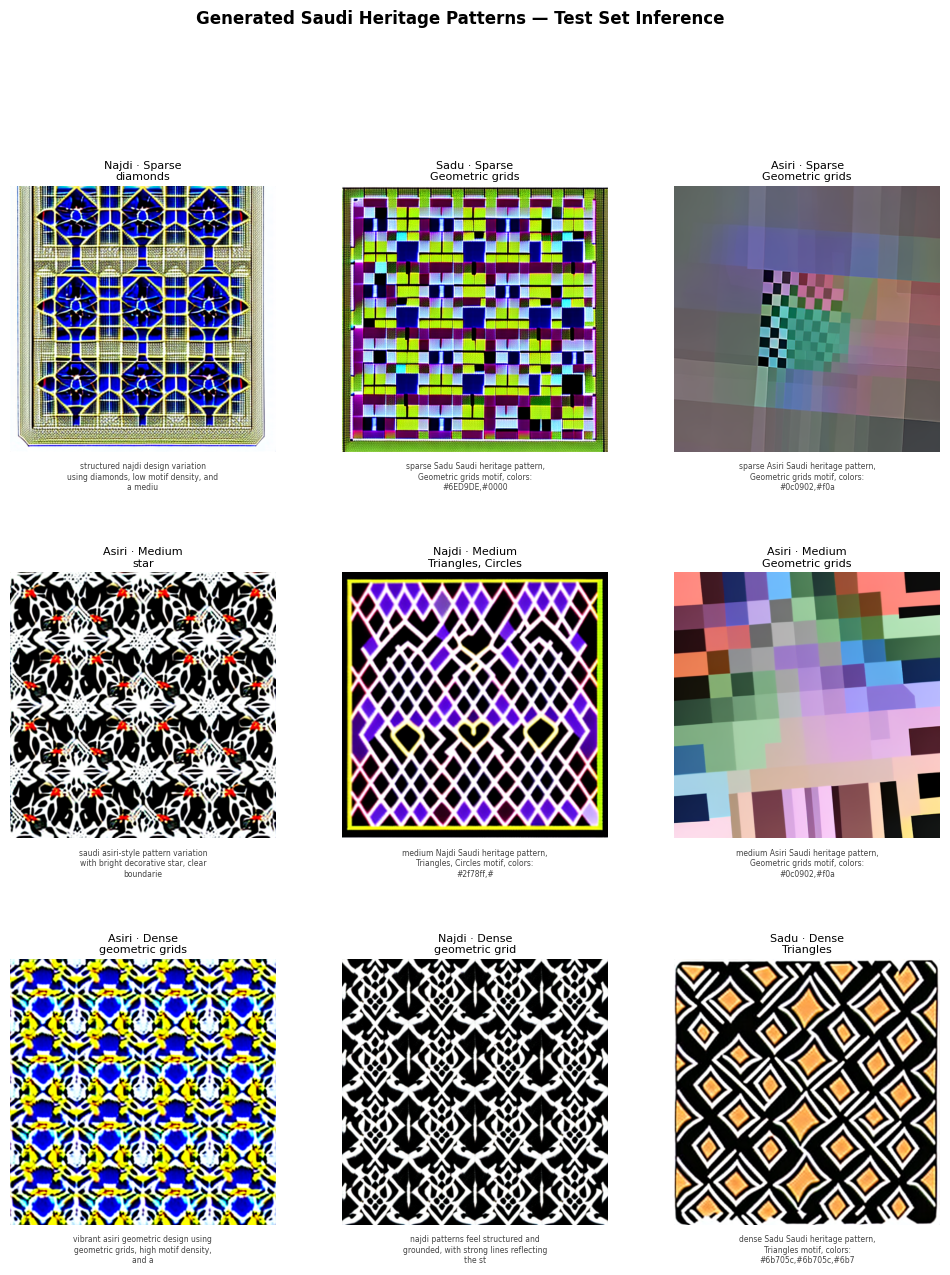

Saved → inference_test_examples.png
  Custom: Sparse — sparse Najdi Saudi heritage pattern, geometric star mot...
  Custom: Medium — medium Sadu Saudi heritage pattern, diamond and zigzag ...
  Custom: Dense — dense Asiri Saudi heritage pattern, floral geometric mo...


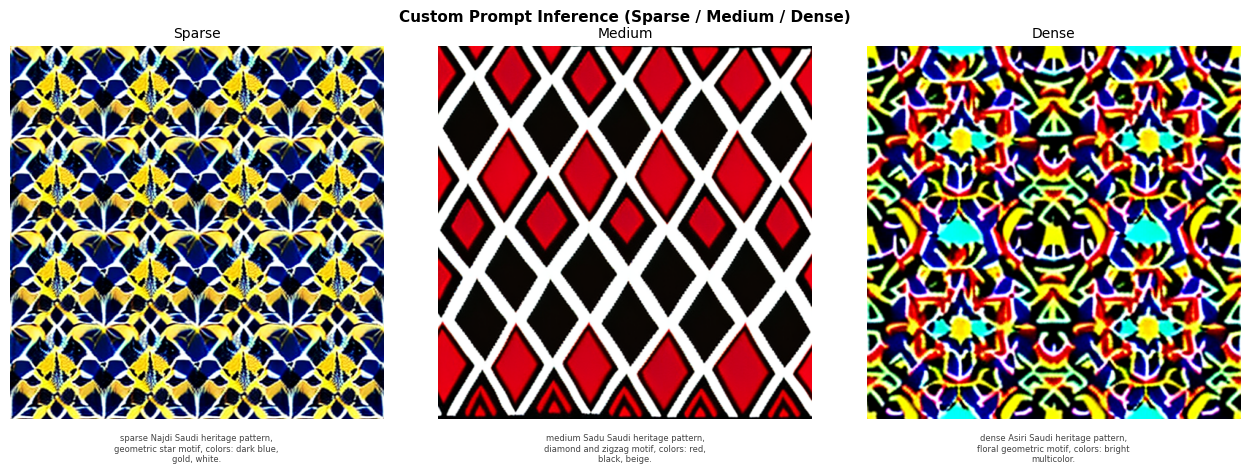

Saved → inference_custom_prompts.png


In [ ]:
# ── Cell 14: Load saved weights & run inference on test examples ─
import math, textwrap
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import numpy as np

# ── Step 1: Load the fine-tuned weights ────────────────────────────
load_trained_model(
    attn_path='heritage_unet_attn.pt',
    embedder_path='heritage_density_embedder.pt',
)
unet.eval()
density_embedder.eval()
print('Model ready for inference.')

# ── Step 2: Pick test examples ─────────────────────────────────────
test_df = pd.read_csv(CFG['test_csv'])

# Sample up to 9 rows — one per Region×Density combo if possible
DENSITIES_ORDER = ['Sparse', 'Medium', 'Dense']
samples = []
for density in DENSITIES_ORDER:
    subset = test_df[test_df['Density'] == density]
    if len(subset) == 0:
        subset = test_df
    rows = subset.sample(min(3, len(subset)), random_state=42)
    samples.extend(rows.to_dict('records'))

samples = samples[:9]   # cap at 9 for a 3×3 grid
print(f'Running inference on {len(samples)} test examples...')

# ── Step 3: Generate + display ─────────────────────────────────────
cols  = 3
rows  = math.ceil(len(samples) / cols)
fig   = plt.figure(figsize=(cols * 4, rows * 4.5))
gs    = gridspec.GridSpec(rows, cols, figure=fig,
                          hspace=0.45, wspace=0.25)

for idx, rec in enumerate(samples):
    desc    = rec['Description']
    density = rec['Density']
    region  = rec['Region']
    motif   = rec.get('Motif', '')

    print(f'  [{idx+1}/{len(samples)}] {region} | {density} — {desc[:60]}...')
    with torch.no_grad():
        gen_np = generate(
            desc,
            density,
            num_steps=CFG['num_inference_steps'],
            guidance_scale=CFG['guidance_scale'],
        )

    ax = fig.add_subplot(gs[idx // cols, idx % cols])
    ax.imshow(gen_np)
    ax.axis('off')

    title = f'{region} · {density}'
    if motif:
        title += f'\n{motif[:30]}'
    ax.set_title(title, fontsize=8, pad=4)

    # Show a snippet of the prompt below the image
    wrapped = textwrap.fill(desc[:80], width=38)
    ax.text(0.5, -0.04, wrapped, transform=ax.transAxes,
            fontsize=5.5, ha='center', va='top', color='#444')

fig.suptitle('Generated Saudi Heritage Patterns — Test Set Inference',
             fontsize=12, y=1.01, fontweight='bold')
plt.savefig('inference_test_examples.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → inference_test_examples.png')

# ── Step 4: Also show a custom prompt example ──────────────────────
CUSTOM_PROMPTS = [
    ('sparse Najdi Saudi heritage pattern, geometric star motif, '
     'colors: dark blue, gold, white.', 'Sparse'),
    ('medium Sadu Saudi heritage pattern, diamond and zigzag motif, '
     'colors: red, black, beige.', 'Medium'),
    ('dense Asiri Saudi heritage pattern, floral geometric motif, '
     'colors: bright multicolor.', 'Dense'),
]

fig2, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (prompt, density) in zip(axes, CUSTOM_PROMPTS):
    print(f'  Custom: {density} — {prompt[:55]}...')
    with torch.no_grad():
        img = generate(prompt, density,
                       num_steps=CFG['num_inference_steps'],
                       guidance_scale=CFG['guidance_scale'])
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(density, fontsize=10)
    wrapped = textwrap.fill(prompt[:90], width=40)
    ax.text(0.5, -0.04, wrapped, transform=ax.transAxes,
            fontsize=6, ha='center', va='top', color='#444')

fig2.suptitle('Custom Prompt Inference (Sparse / Medium / Dense)',
              fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('inference_custom_prompts.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → inference_custom_prompts.png')

# Inferane

In [34]:
# ── Standalone Interactive Inference Dashboard ────────────────────────
# Self-contained: run this cell alone (no other cells needed).
# Requirements: heritage_unet_attn.pt  &  heritage_density_embedder.pt
#               saved in Google Drive at the paths below.

# ── 0. Mount Drive & install ipywidgets if needed ─────────────────────


# ── 1. Imports ────────────────────────────────────────────────────────
import os, math, textwrap, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

import torch
import torch.nn as nn
import torch.nn.functional as F
from diffusers import AutoencoderKL, UNet2DConditionModel, DDIMScheduler
from transformers import CLIPTokenizer, CLIPTextModel

# ── 2. Config ─────────────────────────────────────────────────────────
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SD_MODEL = 'runwayml/stable-diffusion-v1-5'


TEST_CSV  = '/content/test.csv'
ATTN_PATH = '/content/heritage_unet_attn.pt'
EMBD_PATH = '/content/heritage_density_embedder.pt'

CFG = {
    'test_csv'            : TEST_CSV,
    'image_size'          : 512,
    'latent_size'         : 64,
    'num_inference_steps' : 30,
    'guidance_scale'      : 7.5,
}
DENSITY_MAP = {'Sparse': 0, 'Medium': 1, 'Dense': 2}
print(f'Device: {device}')

# ── 3. Load frozen SD 1.5 backbone ────────────────────────────────────
print('Loading VAE ...')
vae = AutoencoderKL.from_pretrained(
    'stabilityai/sd-vae-ft-mse', torch_dtype=torch.float32
).to(device)
vae.requires_grad_(False); vae.eval()

print('Loading CLIP ...')
tokenizer    = CLIPTokenizer.from_pretrained(SD_MODEL, subfolder='tokenizer')
text_encoder = CLIPTextModel.from_pretrained(
    SD_MODEL, subfolder='text_encoder', torch_dtype=torch.float32
).to(device)
text_encoder.requires_grad_(False); text_encoder.eval()
CLIP_DIM = text_encoder.config.hidden_size

print('Loading UNet ...')
unet = UNet2DConditionModel.from_pretrained(
    SD_MODEL, subfolder='unet', torch_dtype=torch.float32
).to(device)
try:
    unet.enable_xformers_memory_efficient_attention()
    print('  xformers enabled')
except Exception:
    pass

# ── 4. CADC DensityEmbedder ───────────────────────────────────────────
class DensityEmbedder(nn.Module):
    def __init__(self, clip_hidden_size=768, density_hidden=256):
        super().__init__()
        self.embed = nn.Embedding(3, density_hidden)
        self.proj  = nn.Sequential(
            nn.Linear(density_hidden, density_hidden * 2),
            nn.SiLU(),
            nn.Linear(density_hidden * 2, clip_hidden_size),
            nn.LayerNorm(clip_hidden_size),
        )
    def forward(self, density_ids):
        return self.proj(self.embed(density_ids)).unsqueeze(1)

density_embedder = DensityEmbedder(clip_hidden_size=CLIP_DIM).to(device)

# ── 5. Conditioning helpers ───────────────────────────────────────────
def encode_conditions(descriptions, density_ids):
    toks = tokenizer(descriptions, padding='max_length', max_length=77,
                     truncation=True, return_tensors='pt').to(device)
    with torch.no_grad():
        te = text_encoder(**toks).last_hidden_state
    dt = density_embedder(density_ids.to(device))
    return torch.cat([te, dt], dim=1)

def encode_uncond(batch_size):
    toks = tokenizer([''] * batch_size, padding='max_length', max_length=77,
                     truncation=True, return_tensors='pt').to(device)
    with torch.no_grad():
        te = text_encoder(**toks).last_hidden_state
    neutral = torch.ones(batch_size, dtype=torch.long, device=device)
    dt = density_embedder(neutral)
    return torch.cat([te, dt], dim=1)

# ── 6. DDIM generate ──────────────────────────────────────────────────
@torch.no_grad()
def generate(description, density, num_steps=None, guidance_scale=None):
    unet.eval(); density_embedder.eval()
    num_steps      = num_steps      or CFG['num_inference_steps']
    guidance_scale = guidance_scale or CFG['guidance_scale']
    density_id = torch.tensor([DENSITY_MAP.get(density, 1)], device=device)
    cond   = encode_conditions([description], density_id)
    uncond = encode_uncond(1)
    ddim   = DDIMScheduler.from_pretrained(SD_MODEL, subfolder='scheduler')
    ddim.set_timesteps(num_steps, device=device)
    z = torch.randn(1, 4, CFG['latent_size'], CFG['latent_size'], device=device)
    z = z * ddim.init_noise_sigma
    for t in ddim.timesteps:
        z_in = torch.cat([z, z])
        e_in = torch.cat([uncond, cond])
        t_in = t.reshape(1).expand(2)
        pred = unet(z_in, t_in, encoder_hidden_states=e_in).sample
        pu, pc = pred.chunk(2)
        z = ddim.step(pu + guidance_scale * (pc - pu), t, z).prev_sample
    img = vae.decode(z / 0.18215).sample
    img = ((img.clamp(-1, 1) + 1) / 2)[0].permute(1, 2, 0).cpu().numpy()
    return (img * 255).astype(np.uint8)

# ── 7. Load fine-tuned weights ────────────────────────────────────────
def load_trained_model(attn_path=ATTN_PATH, embedder_path=EMBD_PATH):
    global unet, density_embedder
    attn_state = torch.load(attn_path, map_location=device)
    _, unexpected = unet.load_state_dict(attn_state, strict=False)
    print(f'  Attention weights: {len(attn_state)} tensors loaded')
    if unexpected:
        print(f'  Unexpected keys: {unexpected[:3]}')
    density_embedder = DensityEmbedder(clip_hidden_size=CLIP_DIM).to(device)
    density_embedder.load_state_dict(torch.load(embedder_path, map_location=device))
    print(f'  DensityEmbedder loaded')

print('Loading fine-tuned weights ...')
load_trained_model()
unet.eval(); density_embedder.eval()
print('Model ready.')

# ═══════════════════════════════════════════════════════════════════════
# 8. INTERACTIVE DASHBOARD
# ═══════════════════════════════════════════════════════════════════════

EXAMPLE_PROMPTS = [
    ('sparse Najdi Saudi heritage pattern, geometric star motif, '
     'colors: dark blue, gold, white.', 'Sparse'),
    ('medium Sadu Saudi heritage pattern, diamond and zigzag motif, '
     'colors: red, black, beige.', 'Medium'),
    ('dense Asiri Saudi heritage pattern, floral geometric motif, '
     'colors: bright multicolor.', 'Dense'),
    ('sparse Hijazi Saudi heritage pattern, crescent and arch motif, '
     'colors: teal, ivory, copper.', 'Sparse'),
    ('dense Najdi Saudi heritage pattern, diamond lattice motif, '
     'colors: deep red, black, gold.', 'Dense'),
    ('medium Asiri Saudi heritage pattern, triangular mountain motif, '
     'colors: orange, white, brown.', 'Medium'),
]

# ── Widgets ───────────────────────────────────────────────────────────
style   = {'description_width': '90px'}
layout  = widgets.Layout(width='98%')

prompt_box = widgets.Textarea(
    value='dense Najdi Saudi heritage geometric pattern, '
          'traditional diamond motifs with warm earth tone colors, '
          'intricate symmetrical repetition.',
    description='Prompt:',
    layout=widgets.Layout(width='98%', height='80px'),
    style=style,
)
density_dd = widgets.Dropdown(
    options=['Sparse', 'Medium', 'Dense'],
    value='Dense',
    description='Density:',
    style=style, layout=widgets.Layout(width='220px'),
)
steps_slider = widgets.IntSlider(
    value=30, min=10, max=50, step=5,
    description='Steps:',
    style=style, layout=widgets.Layout(width='340px'),
    continuous_update=False,
)
guidance_slider = widgets.FloatSlider(
    value=7.5, min=3.0, max=15.0, step=0.5,
    description='Guidance:',
    style=style, layout=widgets.Layout(width='340px'),
    readout_format='.1f', continuous_update=False,
)
generate_btn = widgets.Button(
    description='Generate', button_style='success',
    icon='paint-brush', layout=widgets.Layout(width='160px', height='38px'),
)
examples_btn = widgets.Button(
    description='Show Examples', button_style='info',
    icon='th', layout=widgets.Layout(width='160px', height='38px'),
)
save_btn = widgets.Button(
    description='Save Last Image', button_style='warning',
    icon='floppy-o', layout=widgets.Layout(width='160px', height='38px'),
)
status_lbl = widgets.HTML(value='<i>Ready.</i>')
out_single  = widgets.Output()
out_gallery = widgets.Output()

# Quick-fill buttons for example prompts
fill_btns = [
    widgets.Button(
        description=f'Ex {i+1}: {d}',
        button_style='',
        layout=widgets.Layout(width='auto'),
        tooltip=p,
    )
    for i, (p, d) in enumerate(EXAMPLE_PROMPTS)
]

_last_image = [None]   # store last generated numpy image

def on_fill(btn):
    for i, b in enumerate(fill_btns):
        if b is btn:
            p, d = EXAMPLE_PROMPTS[i]
            prompt_box.value  = p
            density_dd.value  = d
            break

for b in fill_btns:
    b.on_click(on_fill)

def on_generate(btn):
    status_lbl.value = '<b style="color:#1a73e8">Generating... please wait.</b>'
    generate_btn.disabled = True
    with out_single:
        clear_output(wait=True)
        try:
            img_np = generate(
                prompt_box.value.strip(),
                density_dd.value,
                num_steps=steps_slider.value,
                guidance_scale=guidance_slider.value,
            )
            _last_image[0] = img_np
            fig, ax = plt.subplots(1, 1, figsize=(5, 5))
            ax.imshow(img_np)
            ax.axis('off')
            wrapped = textwrap.fill(prompt_box.value.strip()[:100], width=60)
            ax.set_title(
                f'{density_dd.value}  |  steps={steps_slider.value}  '
                f'guidance={guidance_slider.value}',
                fontsize=9, pad=6,
            )
            ax.text(0.5, -0.03, wrapped, transform=ax.transAxes,
                    fontsize=6.5, ha='center', va='top', color='#333')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f'Error: {e}')
    status_lbl.value = '<b style="color:green">Done!</b>'
    generate_btn.disabled = False

def on_examples(btn):
    status_lbl.value = '<b style="color:#1a73e8">Generating examples grid...</b>'
    examples_btn.disabled = True
    with out_gallery:
        clear_output(wait=True)
        try:
            n    = len(EXAMPLE_PROMPTS)
            cols = 3
            rows = math.ceil(n / cols)
            fig  = plt.figure(figsize=(cols * 4.5, rows * 5))
            gs   = gridspec.GridSpec(rows, cols, figure=fig,
                                     hspace=0.50, wspace=0.25)
            for idx, (prompt, density) in enumerate(EXAMPLE_PROMPTS):
                print(f'  [{idx+1}/{n}] {density} ...')
                img_np = generate(prompt, density)
                ax = fig.add_subplot(gs[idx // cols, idx % cols])
                ax.imshow(img_np)
                ax.axis('off')
                ax.set_title(density, fontsize=9, pad=4)
                wrapped = textwrap.fill(prompt[:75], width=36)
                ax.text(0.5, -0.04, wrapped, transform=ax.transAxes,
                        fontsize=5.5, ha='center', va='top', color='#444')
            fig.suptitle('Example Gallery — Saudi Heritage Patterns',
                         fontsize=12, fontweight='bold', y=1.01)
            plt.savefig('inference_examples_gallery.png',
                        dpi=150, bbox_inches='tight')
            plt.show()
            print('Saved → inference_examples_gallery.png')
        except Exception as e:
            print(f'Error: {e}')
    status_lbl.value = '<b style="color:green">Examples done!</b>'
    examples_btn.disabled = False

def on_save(btn):
    if _last_image[0] is None:
        status_lbl.value = '<b style="color:red">Generate an image first.</b>'
        return
    out_path = 'generated_pattern.png'
    Image.fromarray(_last_image[0]).save(out_path)
    status_lbl.value = f'<b style="color:green">Saved → {out_path}</b>'

generate_btn.on_click(on_generate)
examples_btn.on_click(on_examples)
save_btn.on_click(on_save)

# ── Layout ────────────────────────────────────────────────────────────
fill_row = widgets.HBox(
    fill_btns,
    layout=widgets.Layout(flex_flow='row wrap', gap='6px', margin='4px 0'),
)
controls = widgets.VBox([
    widgets.HTML('<b style="font-size:15px">Saudi Heritage Pattern Generator</b>'),
    widgets.HTML('<small>Quick-fill an example prompt:</small>'),
    fill_row,
    prompt_box,
    widgets.HBox([density_dd, steps_slider, guidance_slider],
                 layout=widgets.Layout(gap='16px', margin='6px 0')),
    widgets.HBox([generate_btn, examples_btn, save_btn],
                 layout=widgets.Layout(gap='10px')),
    status_lbl,
    widgets.HTML('<hr style="margin:8px 0">'),
    widgets.HTML('<b>Single generation output:</b>'),
    out_single,
    widgets.HTML('<b>Examples gallery:</b>'),
    out_gallery,
], layout=widgets.Layout(padding='14px', border='1px solid #ddd',
                          border_radius='8px', width='100%'))

display(controls)


Device: cuda
Loading VAE ...
Loading CLIP ...


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading UNet ...
Loading fine-tuned weights ...
  Attention weights: 160 tensors loaded
  DensityEmbedder loaded
Model ready.
